In [71]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np


In [ ]:

df = pd.read_csv(r'../Datasets/student_dropout.csv')

df = df[['Age', 'Study_Hours_per_Day', 'Attendance_Rate', 'CGPA', 'Dropout']]

df

,Age,Study_Hours_per_Day,Attendance_Rate,CGPA,Dropout
3302,21.5,6.47,95.0,3.97,0
5833,22.8,4.73,91.4,3.27,0
8017,19.4,4.25,73.2,3.40,0
2121,22.7,2.95,78.9,1.53,0
1513,17.0,NaN,44.6,1.35,1


In [59]:

df = df.dropna()

df.sample(5)

,Age,Study_Hours_per_Day,Attendance_Rate,CGPA,Dropout
4559,22.4,4.41,78.6,3.04,0
8307,25.2,5.52,73.9,3.98,0
3963,22.7,6.54,86.2,3.65,0
4199,22.3,4.76,81.1,1.36,0
3567,23.4,5.69,85.4,3.38,0


C:\Users\Muhammad Awais Raza\AppData\Local\Temp\ipykernel_18280\342305554.py:3: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['Study_Hours_per_Day'])


<Axes: xlabel='Study_Hours_per_Day', ylabel='Density'>

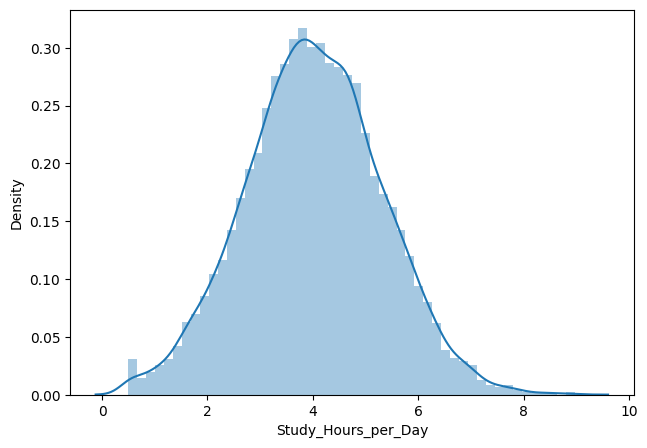

In [54]:
plt.figure(figsize=(16, 5))
plt.subplot(1,2,1)
sns.distplot(df['Study_Hours_per_Day'])

# plt.subplot(1,2,2)
# sns.distplot(df['Age'])

In [42]:
df.isnull().mean()

Age                    0.0
Study_Hours_per_Day    0.0
Attendance_Rate        0.0
CGPA                   0.0
Dropout                0.0
dtype: float64

In [55]:
std = df['Study_Hours_per_Day'].std()

In [56]:
max_limit = df['Study_Hours_per_Day'].mean() + 3*std
min_limit = df['Study_Hours_per_Day'].mean() - 3*std


print('Mean: ', df['Study_Hours_per_Day'].mean())
print('Max limit: ', max_limit)
print('Min limit: ', min_limit)

Mean:  4.0145915789473685
Max limit:  7.900941460985139
Min limit:  0.12824169690959764


#### Trimming

In [63]:
new_df = df[(df['Study_Hours_per_Day'] < max_limit) & (df['Study_Hours_per_Day'] > min_limit)]

In [64]:
new_df

,Age,Study_Hours_per_Day,Attendance_Rate,CGPA,Dropout
0,22.1,3.36,86.1,0.90,0
1,20.7,4.30,68.0,1.19,1
2,22.4,4.40,70.9,1.32,0
4,20.5,4.19,75.7,0.87,0
5,20.5,4.11,89.1,2.69,0
...,...,...,...,...,...
9995,23.9,4.62,92.0,0.97,0
9996,17.0,2.87,75.2,3.09,1
9997,19.4,4.73,74.9,3.43,0
9998,22.1,5.85,74.2,3.34,0


C:\Users\Muhammad Awais Raza\AppData\Local\Temp\ipykernel_18280\1846862487.py:3: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(new_df['Study_Hours_per_Day'])


<Axes: xlabel='Study_Hours_per_Day', ylabel='Density'>

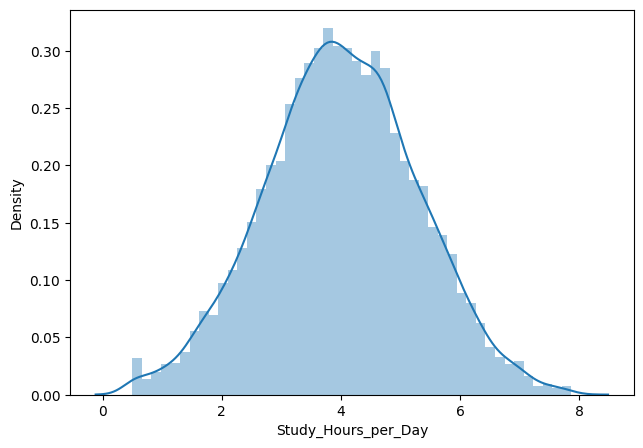

In [65]:
plt.figure(figsize=(16, 5))
plt.subplot(1,2,1)
sns.distplot(new_df['Study_Hours_per_Day'])

### Using z-score

In [66]:
df['Study_Hours_per_Day_zscore'] = (df['Study_Hours_per_Day'] - df['Study_Hours_per_Day'].mean())/df['Study_Hours_per_Day'].std()

df

,Age,Study_Hours_per_Day,Attendance_Rate,CGPA,Dropout,Study_Hours_per_Day_zscore
0,22.1,3.36,86.1,0.90,0,-0.505301
1,20.7,4.30,68.0,1.19,1,0.220316
2,22.4,4.40,70.9,1.32,0,0.297509
4,20.5,4.19,75.7,0.87,0,0.135403
5,20.5,4.11,89.1,2.69,0,0.073649
...,...,...,...,...,...,...
9995,23.9,4.62,92.0,0.97,0,0.467334
9996,17.0,2.87,75.2,3.09,1,-0.883548
9997,19.4,4.73,74.9,3.43,0,0.552247
9998,22.1,5.85,74.2,3.34,0,1.416812


In [69]:
new_df = df[(df['Study_Hours_per_Day_zscore'] > -3) & (df['Study_Hours_per_Day_zscore'] < 3)]

new_df

,Age,Study_Hours_per_Day,Attendance_Rate,CGPA,Dropout,Study_Hours_per_Day_zscore
0,22.1,3.36,86.1,0.90,0,-0.505301
1,20.7,4.30,68.0,1.19,1,0.220316
2,22.4,4.40,70.9,1.32,0,0.297509
4,20.5,4.19,75.7,0.87,0,0.135403
5,20.5,4.11,89.1,2.69,0,0.073649
...,...,...,...,...,...,...
9995,23.9,4.62,92.0,0.97,0,0.467334
9996,17.0,2.87,75.2,3.09,1,-0.883548
9997,19.4,4.73,74.9,3.43,0,0.552247
9998,22.1,5.85,74.2,3.34,0,1.416812


#### Capping

In [ ]:
df['Study_Hours_per_Day'] = df['Study_Hours_per_Day'] = np.where(
    df['Study_Hours_per_Day'] > max_limit,
    max_limit,
    np.where(
        df['Study_Hours_per_Day'] < min_limit,
        min_limit,
        df['Study_Hours_per_Day']
    )
)

In [78]:
print(np.where(
    df['Study_Hours_per_Day'] == max_limit
))

df.describe()

(array([ 212,  754, 1180, 1214, 1599, 2177, 2394, 3239, 3693, 4638, 5322,
       5449, 5940, 7310, 7577, 8179, 8207, 9414]),)


,Age,Study_Hours_per_Day,Attendance_Rate,CGPA,Dropout,Study_Hours_per_Day_zscore
count,9500.000000,9500.000000,9500.000000,9500.000000,9500.000000,9.500000e+03
mean,21.025621,4.013824,81.968695,2.295297,0.235895,-6.768854e-17
std,2.141617,1.292942,7.970245,1.072487,0.424579,1.000000e+00
min,17.000000,0.500000,50.000000,0.000000,0.000000,-2.713028e+00
25%,19.500000,3.160000,76.600000,1.520000,0.000000,-6.596871e-01
50%,21.000000,4.000000,82.000000,2.350000,0.000000,-1.126371e-02
75%,22.500000,4.870000,87.400000,3.140000,0.000000,6.603176e-01
max,29.600000,7.900941,100.000000,4.000000,1.000000,3.832960e+00
